## <B> Factory to Customer Shipping Route Efficiency Analysis <B>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

In [4]:
# Load the dataset
df = pd.read_csv("../data/Nassau-Candy-Distributor.csv")

# Display first five rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,3/1/2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,4/1/2024,1/7/2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,4/1/2024,1/7/2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,4/1/2024,1/7/2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,5/1/2024,5/7/2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [5]:
# Display last five rows
df.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
10189,10190,US-2024-143259-CHO-MIL-31000,30-12-2025,26-06-2030,Standard Class,143259,United States,New York City,New York,10009,Chocolate,Atlantic,CHO-MIL-31000,Wonka Bar - Milk Chocolate,9.75,3,6.33,3.42
10190,10191,US-2024-115427-CHO-NUT-13000,30-12-2025,26-06-2030,Standard Class,115427,United States,Fairfield,California,94533,Chocolate,Pacific,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,6.98,2,4.98,2.00
10191,10192,US-2024-156720-CHO-SCR-58000,30-12-2025,26-06-2030,Standard Class,156720,United States,Loveland,Colorado,80538,Chocolate,Pacific,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
10192,10193,US-2024-143259-CHO-TRI-54000,30-12-2025,26-06-2030,Standard Class,143259,United States,New York City,New York,10009,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,26.25,7,17.15,9.10
10193,10194,CA-2024-143500-CHO-SCR-58000,30-12-2025,26-06-2030,Standard Class,143500,Canada,Charlottetown,Prince Edward Island,C0A,Chocolate,Atlantic,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30


In [6]:
# Show how many rows and columns in dataset

print("Dataset Shape :")

print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Dataset Shape :
Rows    : 10194
Columns : 18


### Observation
- The dataset contains 10,194 records and 18 features.
- Each record represents order/shipping-related information containing customer,
  product, geographic, financial, and shipping attributes.

In [7]:
# # print name of all column
# df.columns

print("Column Names :")

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Column Names :
1. Row ID
2. Order ID
3. Order Date
4. Ship Date
5. Ship Mode
6. Customer ID
7. Country/Region
8. City
9. State/Province
10. Postal Code
11. Division
12. Region
13. Product ID
14. Product Name
15. Sales
16. Units
17. Gross Profit
18. Cost


In [8]:
# print information about dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  str    
 2   Order Date      10194 non-null  str    
 3   Ship Date       10194 non-null  str    
 4   Ship Mode       10194 non-null  str    
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  str    
 7   City            10194 non-null  str    
 8   State/Province  10194 non-null  str    
 9   Postal Code     10194 non-null  str    
 10  Division        10194 non-null  str    
 11  Region          10194 non-null  str    
 12  Product ID      10194 non-null  str    
 13  Product Name    10194 non-null  str    
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null  float64
dt

In [9]:
# print datatypes of all column
print("Data Types :")

df.dtypes

Data Types :


Row ID              int64
Order ID              str
Order Date            str
Ship Date             str
Ship Mode             str
Customer ID         int64
Country/Region        str
City                  str
State/Province        str
Postal Code           str
Division              str
Region                str
Product ID            str
Product Name          str
Sales             float64
Units               int64
Gross Profit      float64
Cost              float64
dtype: object

In [10]:
# Numerical columns
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
print(f"Number of Numerical Columns   : {len(numerical_columns)}")

# Categorical columns
categorical_columns = df.select_dtypes(include=["object"]).columns.tolist()
print(f"Number of Categorical Columns : {len(categorical_columns)}")

Number of Numerical Columns   : 6
Number of Categorical Columns : 12


In [11]:
print("Numerical Columns")
print("-" * 40)
for col in numerical_columns:
    print(col)

print("=" * 40)

print("Categorical Columns")
print("-" * 40)
for col in categorical_columns:
    print(col)
    
# print(f"Numerical Columns   : {numerical_columns}")
# print(f"Categorical Columns   : {categorical_columns}")

Numerical Columns
----------------------------------------
Row ID
Customer ID
Sales
Units
Gross Profit
Cost
Categorical Columns
----------------------------------------
Order ID
Order Date
Ship Date
Ship Mode
Country/Region
City
State/Province
Postal Code
Division
Region
Product ID
Product Name


## Observation

- The dataset contains **10,194 records** and **18 features**.
- There are **6 numerical columns** and **12 categorical columns**.
- The `Order Date` and `Ship Date` columns are currently stored as `object` and must be converted to `datetime`.
- The dataset contains customer, product, geographic, shipping, and financial information required for route efficiency analysis.
- No missing values are apparent from the `df.info()` output.

## **Missing Values Analysis**

In [12]:
# Check missing value
print("Missing Values :")
df.isnull().sum()

Missing Values :


Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Division          0
Region            0
Product ID        0
Product Name      0
Sales             0
Units             0
Gross Profit      0
Cost              0
dtype: int64

In [13]:
# missing_values = pd.DataFrame({
#     "Missing Values": df.isnull().sum(),
#     "Percentage": (df.isnull().sum() / len(df)) * 100
# })

# missing_values

missing_summary = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage (%)": (
        df.isnull().sum() / len(df) * 100
    ).round(2)
})

missing_summary

,Missing Count,Missing Percentage (%)
Row ID,0,0.0
Order ID,0,0.0
Order Date,0,0.0
Ship Date,0,0.0
Ship Mode,0,0.0
Customer ID,0,0.0
Country/Region,0,0.0
City,0,0.0
State/Province,0,0.0
Postal Code,0,0.0


In [14]:
missing_summary[
    missing_summary["Missing Count"] > 0
]

,Missing Count,Missing Percentage (%)


## Observation

- All 18 columns contain complete data.
- No missing values were detected in the dataset.
- Missing value imputation is not required.
- The dataset is ready for further quality checks.

## **Duplicated Values Analysis**

In [15]:
# check duplocated values

duplicated_count = df.duplicated().sum()

print(f"Total Duplicated Rows: {duplicated_count}")

Total Duplicated Rows: 0


In [16]:
duplicate_count = df.duplicated().sum()

duplicate_count

np.int64(0)

In [17]:
duplicate_percentage = round(
    duplicate_count / len(df) * 100,
    2
)

print(f"Duplicate Percentage: {duplicate_percentage}%")

Duplicate Percentage: 0.0%


## Observation

- No duplicate records were found in the dataset.
- Duplicate percentage is 0.0%.
- Each row represents a unique transaction.
- The dataset passes the duplicate record quality check.

## **Date Conversion & Feature Engineering**

In [18]:
# Check current Datatypes 
print(df[["Order Date", "Ship Date"]])

       Order Date   Ship Date
0        3/1/2024  30-06-2026
1        4/1/2024    1/7/2026
2        4/1/2024    1/7/2026
3        4/1/2024    1/7/2026
4        5/1/2024    5/7/2026
...           ...         ...
10189  30-12-2025  26-06-2030
10190  30-12-2025  26-06-2030
10191  30-12-2025  26-06-2030
10192  30-12-2025  26-06-2030
10193  30-12-2025  26-06-2030

[10194 rows x 2 columns]


In [19]:
# Convert Order Date and Ship Date to datetime
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    format="mixed"
    )

df["Ship Date"] = pd.to_datetime(
    df["Ship Date"],
    format="mixed" )

### Create Shipping Days Feature

In [20]:
# Calculate shipping duration
df["Shipping Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

In [21]:
df[["Order Date", "Ship Date", "Shipping Days"]].head(10)

,Order Date,Ship Date,Shipping Days
0,2024-03-01,2026-06-30,851
1,2024-04-01,2026-01-07,646
2,2024-04-01,2026-01-07,646
3,2024-04-01,2026-01-07,646
4,2024-05-01,2026-05-07,736
5,2024-06-01,2026-03-07,644
6,2024-06-01,2026-03-07,644
7,2024-06-01,2026-06-30,759
8,2024-06-01,2026-03-07,644
9,2024-06-01,2026-03-07,644


In [22]:
# Check Shipping Days Statistics
df["Shipping Days"].describe()

count    10194.000000
mean      1344.239356
std        294.675072
min        491.000000
25%       1194.000000
50%       1276.000000
75%       1638.000000
max       1965.000000
Name: Shipping Days, dtype: float64

In [23]:
# Check Minimum and Maximum Shipping Days
print(f"Minimum Shiping Days : {df["Shipping Days"].min()}")
print(f"Maximum Shiping Days : {df["Shipping Days"].max()}")

Minimum Shiping Days : 491
Maximum Shiping Days : 1965


In [24]:
# Check For Negative Days
negative_days = df[df["Shipping Days"] < 0]

print(f"Negative Shipping Records : {len(negative_days)}")

Negative Shipping Records : 0


In [25]:
same_day_shipping = df[df["Shipping Days"] == 0]

print(f"Same Day Orders : {len(same_day_shipping)}")

Same Day Orders : 0


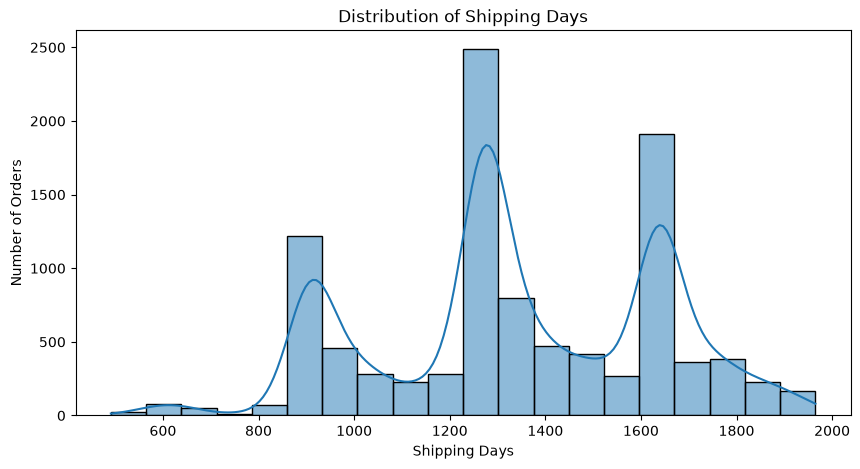

In [26]:
plt.figure(figsize=(10, 5))

sns.histplot(df["Shipping Days"], bins=20, kde=True)

plt.title("Distribution of Shipping Days")
plt.xlabel("Shipping Days")
plt.ylabel("Number of Orders")

plt.show()

## Histogram Observation

- The distribution of shipping days is multimodal, with multiple distinct peaks.
- Most orders are concentrated around 1200–1300 shipping days.
- A secondary concentration appears around 1600–1700 shipping days.
- Shipping durations exhibit high variability across orders.
- No negative shipping durations were found.
- The unusually large shipping durations suggest that the dataset may be synthetic or generated for analytical purposes.

In [27]:
df.groupby("Ship Mode")["Shipping Days"].agg(
    ["count", "mean", "min", "max"]
).round(2)

,count,mean,min,max
Ship Mode,,,,
First Class,1548,1360.13,522,1961
Same Day,547,1356.49,727,1929
Second Class,1979,1352.12,491,1960
Standard Class,6120,1336.58,552,1965


## Ship Mode Observation

- Shipping duration varies only slightly across ship modes.
- Standard Class has the lowest average shipping duration, while First Class has the highest.
- The expected operational ordering of shipping modes is not observed.
- This suggests that the dataset is likely synthetic or intended for analytical practice rather than representing actual logistics operations.
- Despite this limitation, Shipping Days remains useful for comparative analysis within this dataset.

## **Descriptive Statistics & Business Metrics**

In [28]:
# statistical summary
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Row ID,10194.0,5097.5,1.0,2549.25,5097.5,7645.75,10194.0,2942.898656
Order Date,10194,2025-02-22 04:56:38.705120,2024-01-02 00:00:00,2024-09-17 00:00:00,2025-03-11 00:00:00,2025-08-23 00:00:00,2025-12-31 00:00:00,NaN
Ship Date,10194,2028-10-28 10:41:19.105356,2026-01-07 00:00:00,2027-11-12 00:00:00,2028-12-18 00:00:00,2029-11-09 00:00:00,2030-12-06 00:00:00,NaN
Customer ID,10194.0,134468.961154,100006.0,117212.0,133550.0,152051.0,192314.0,20231.483007
Sales,10194.0,13.908537,1.25,7.2,10.8,18.0,260.0,11.34102
Units,10194.0,3.791838,1.0,2.0,3.0,5.0,14.0,2.228317
Gross Profit,10194.0,9.166451,0.25,4.9,7.47,12.25,130.0,6.64374
Cost,10194.0,4.742087,0.6,2.4,3.6,5.7,130.0,5.061647
Shipping Days,10194.0,1344.239356,491.0,1194.0,1276.0,1638.0,1965.0,294.675072


In [29]:
# Budiness matrix Summary
business_metrics = df[
    ["Sales", "Units", "Cost", "Gross Profit", "Shipping Days"]
].describe().T

business_metrics

,count,mean,std,min,25%,50%,75%,max
Sales,10194.0,13.908537,11.341020,1.25,7.2,10.80,18.00,260.0
Units,10194.0,3.791838,2.228317,1.00,2.0,3.00,5.00,14.0
Cost,10194.0,4.742087,5.061647,0.60,2.4,3.60,5.70,130.0
Gross Profit,10194.0,9.166451,6.643740,0.25,4.9,7.47,12.25,130.0
Shipping Days,10194.0,1344.239356,294.675072,491.00,1194.0,1276.00,1638.00,1965.0


In [30]:
# Add Proffit Margin
df["Profit Margin (%)"] = (
    df["Gross Profit"] / df["Sales"]
) * 100

In [31]:
df[["Sales", "Gross Profit", "Profit Margin (%)"]].head()

,Sales,Gross Profit,Profit Margin (%)
0,6.50,4.22,64.923077
1,7.50,4.90,65.333333
2,10.47,7.47,71.346705
3,10.80,7.50,69.444444
4,11.25,7.35,65.333333


In [32]:
# Statistical Summary of Proffit Margin
df["Profit Margin (%)"].describe()

count    10194.000000
mean        66.514045
std          6.721012
min          7.692308
25%         65.333333
50%         66.666667
75%         69.444444
max         80.000000
Name: Profit Margin (%), dtype: float64

In [33]:
total_sales = df["Sales"].sum()

total_profit = df["Gross Profit"].sum()

total_cost = df["Cost"].sum()

total_units = df["Units"].sum()

average_shipping = df["Shipping Days"].mean()

average_profit_margin = df["Profit Margin (%)"].mean()

In [34]:
print("=" * 50)
print("Business KPIs")
print("=" * 50)

print(f"Total Sales            : ${total_sales:,.2f}")
print(f"Total Gross Profit     : ${total_profit:,.2f}")
print(f"Total Cost             : ${total_cost:,.2f}")
print(f"Total Units Sold       : {total_units:,}")
print(f"Average Shipping Days  : {average_shipping:.2f} Days")
print(f"Average Profit Margin  : {average_profit_margin:.2f}%")

Business KPIs
Total Sales            : $141,783.63
Total Gross Profit     : $93,442.80
Total Cost             : $48,340.83
Total Units Sold       : 38,654
Average Shipping Days  : 1344.24 Days
Average Profit Margin  : 66.51%


## Business Metric Observations

- Total Sales represent the overall revenue generated across all orders.
- Gross Profit indicates the profit earned before operational expenses.
- Profit Margin (%) measures the profitability of each sale.
- Shipping Days has a high average because of the dataset's synthetic nature.
- These KPIs will be displayed on the Streamlit dashboard.

## **Univariate Analysis**
The goal is to understand each numerical variable individually.

In [35]:
def plot_distribution(column):
    """
    Plot histogram and boxplot for a numerical feature.
    """

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histogram
    sns.histplot(df[column], bins=30, kde=True, ax=axes[0])

    axes[0].set_title(f"{column} Distribution")

    # Boxplot
    sns.boxplot(x=df[column], ax=axes[1])

    axes[1].set_title(f"{column} Boxplot")

    plt.tight_layout()

    plt.show()

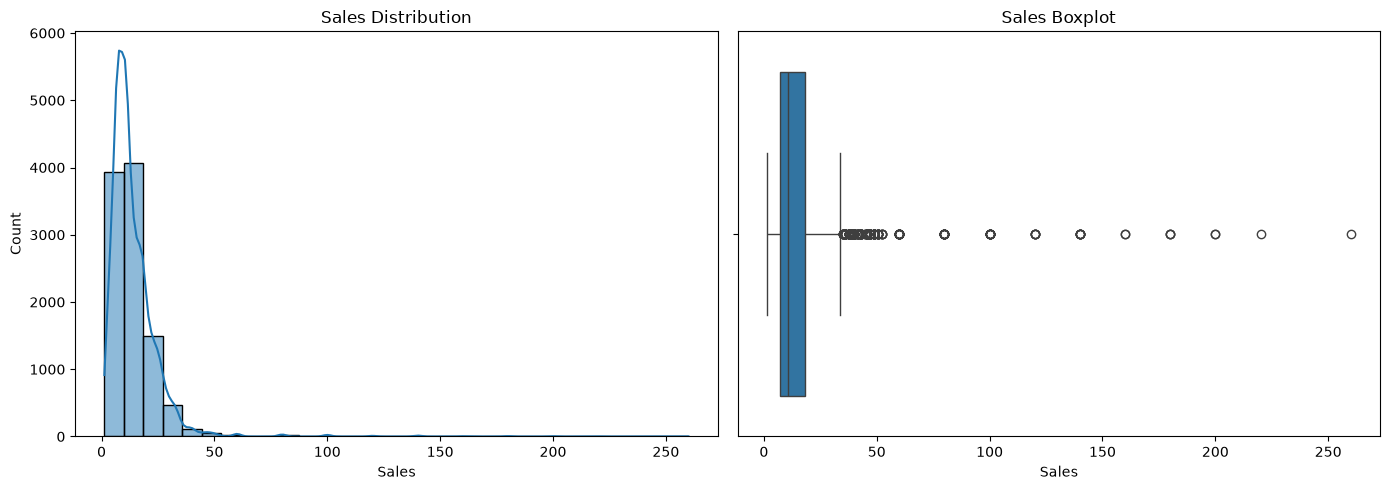

In [36]:
plot_distribution("Sales")

## Sales Distribution

- Distribution is positively (right) skewed.
- Most observations fall between $1 and $20.
- A small number of orders have much higher sales (up to $260).
- The boxplot shows several high-value outliers.

## Business insights:
- Most orders generate relatively low sales, while a small number of high-value orders contribute significantly to total revenue. This is common in retail businesses.


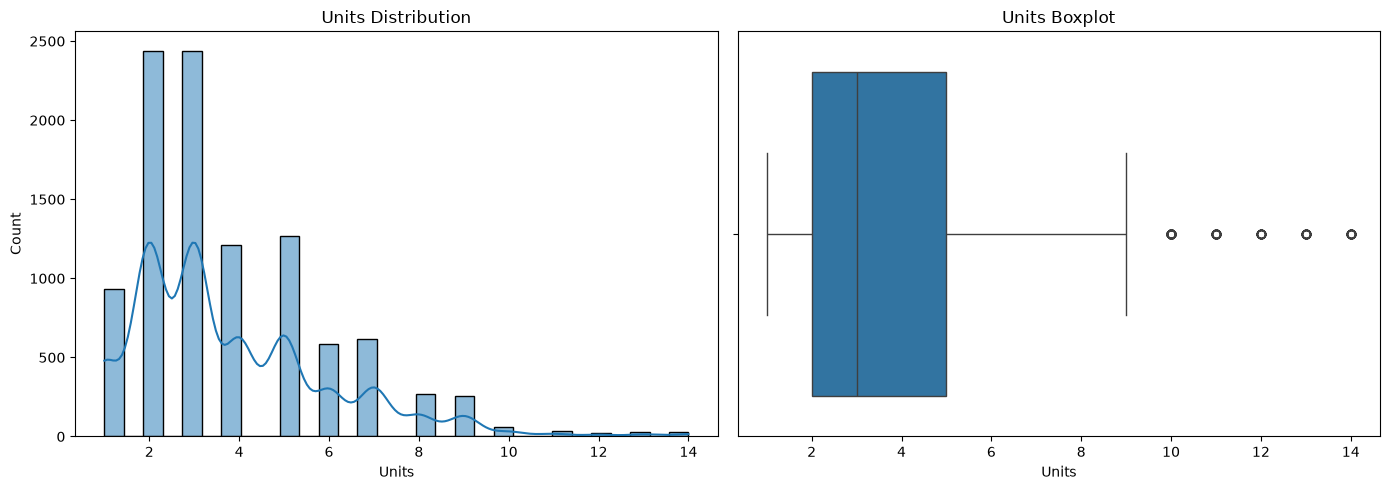

In [37]:
plot_distribution("Units")

## Units Distribution

### Observation
- Units are concentrated between 2 and 5.
- Higher quantities (10–14 units) are rare.
- The distribution is right-skewed.
- The boxplot identifies high-quantity orders as outliers.

### Business insights:
- Most customers purchase only a few units per order, while bulk purchases occur less frequently.


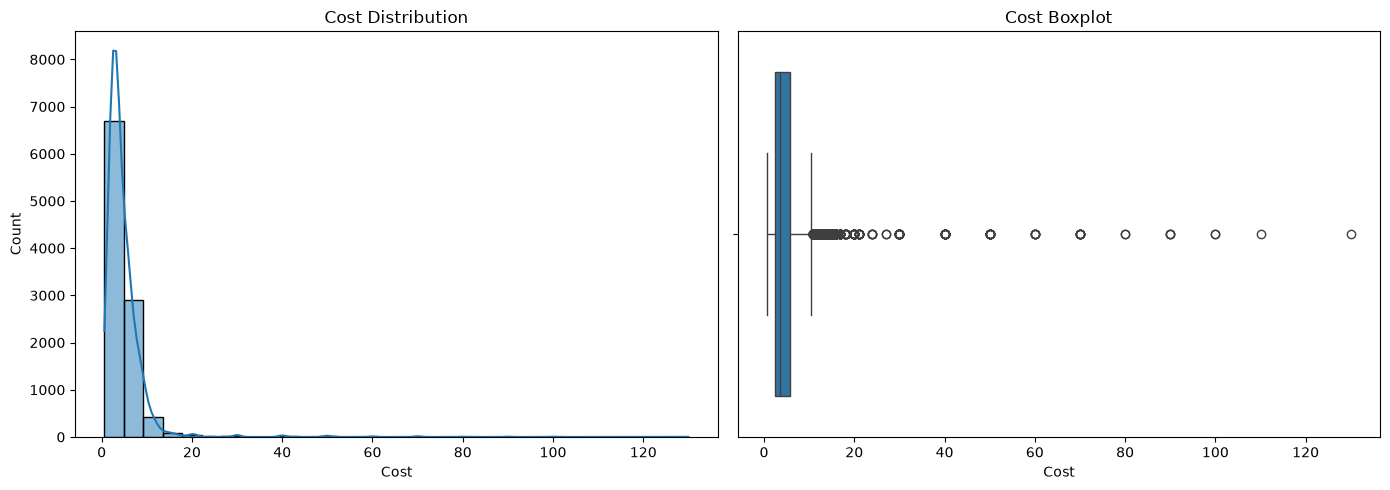

In [38]:
plot_distribution("Cost")

## Cost Distribution

### Observation:

- The distribution is highly right-skewed.
- Most product costs are below $10.
- A few products have substantially higher costs.

### Business Insight:

- The product catalog is dominated by low-cost items, with a small number of premium-cost products.

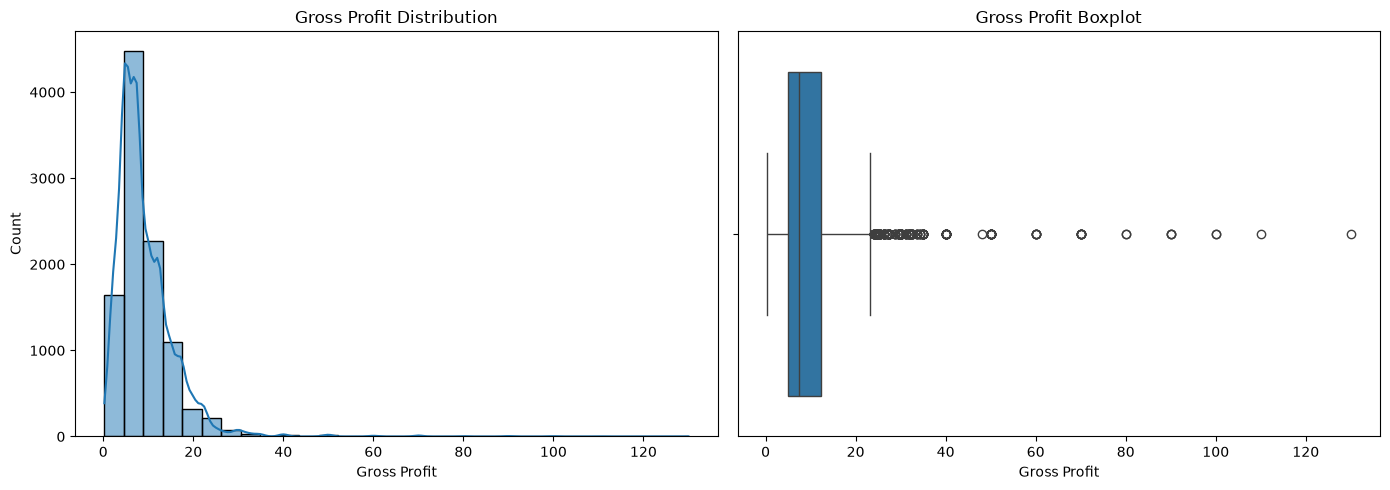

In [39]:
plot_distribution("Gross Profit")

## Gross Profit Distribution 

### Observation:

- Right-skewed distribution.
- Most profits fall between $3 and $15.
- Some orders generate exceptionally high profit.

### Business Insight:

- The majority of orders produce moderate profits, while a limited number of high-profit orders contribute disproportionately to total gross profit.

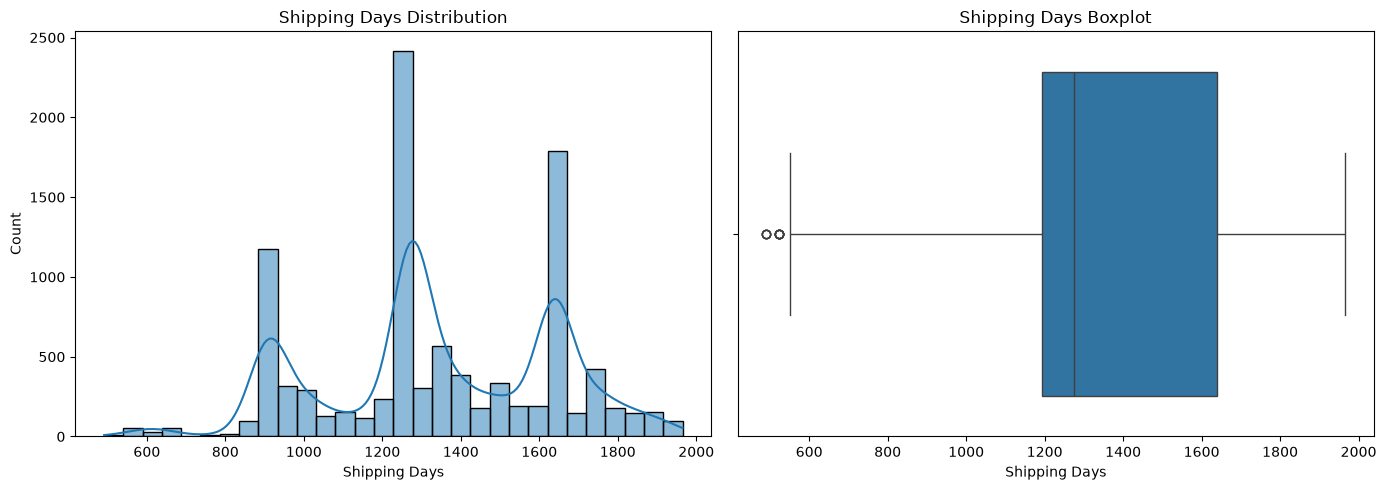

In [40]:
plot_distribution("Shipping Days")

## Shipping Days Distribution 

This is the most important plot.

### Observation:

- The distribution is multimodal (multiple peaks).
- Major peaks are visible around 900, 1200, and 1600 shipping days.
- The boxplot does not show many extreme outliers beyond the existing spread.
- Shipping durations are highly variable.

### Business Insight:

- Shipping durations appear to form multiple clusters rather than a single pattern. Given the unrealistic shipping durations, this likely reflects the synthetic nature of the dataset rather than real operational behavior.

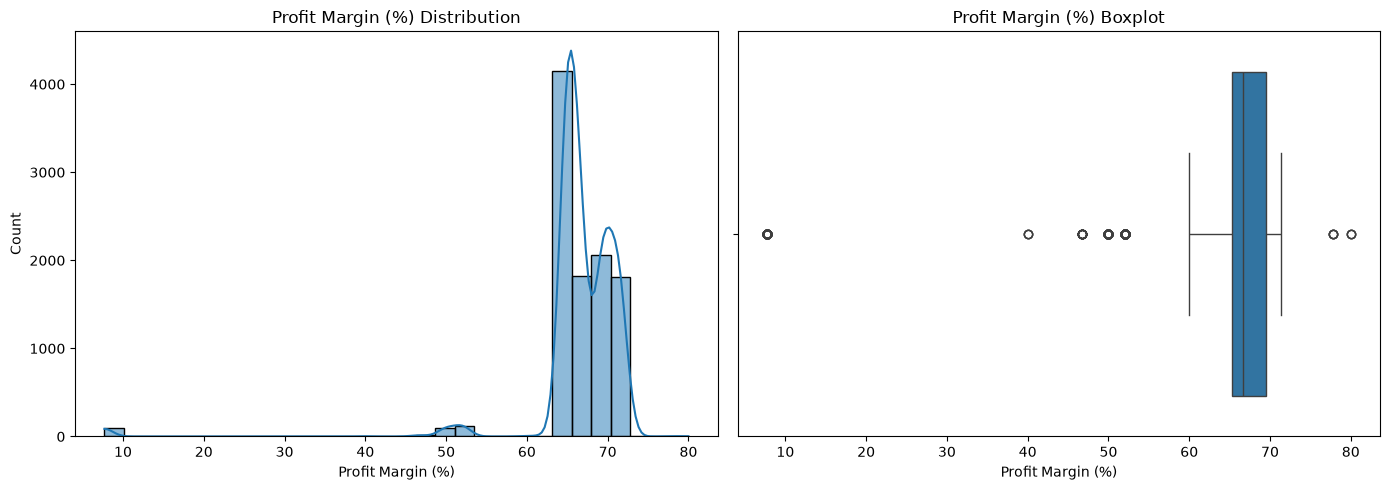

In [41]:
plot_distribution("Profit Margin (%)")

## Profit Margin Distribution 

### Observation:

- Most values are concentrated between 65% and 70%.
- The distribution is fairly compact.
- A few lower and higher profit margins appear as outliers.

### Business Insight:

- Profit margins are generally consistent across products, with only a small number of unusually low or high-margin orders.

## **Univariate Analysis Observations**

### Sales
- Sales distribution is positively skewed.
- Most orders have relatively low sales values.
- A few high-value orders contribute significantly to total sales.

### Units
- Most customers purchase between 2 and 5 units.
- Bulk purchases are relatively uncommon.

### Cost
- Product costs are concentrated at lower values.
- A small number of products have substantially higher costs.

### Gross Profit
- Gross profit is positively skewed.
- Most orders generate moderate profits, with a few high-profit transactions.

### Shipping Days
- Shipping Days exhibits a multimodal distribution.
- Multiple peaks suggest different shipment groups or synthetic data generation patterns.
- Shipping durations show considerable variability.

### Profit Margin
- Profit margins are concentrated around 65–70%.
- A few observations have unusually low or high margins.

### Outlier Decision
- Outliers are retained because they represent valid business transactions rather than data quality issues.
- Since this project focuses on business analytics and dashboard reporting instead of predictive modeling, retaining these values preserves the integrity of the analysis.

## **Bivariate Analysos**

### Objective

Analyze the relationship between two variables to answer business questions.

### We'll answer:

- Which ship mode generates the highest sales?
- Which ship mode generates the highest profit?
- Which ship mode has the highest average shipping days?
- Which region generates the highest sales?
- Which region generates the highest profit?
- Which region has the highest shipping days?
- Is there a relationship between Sales and Gross Profit?

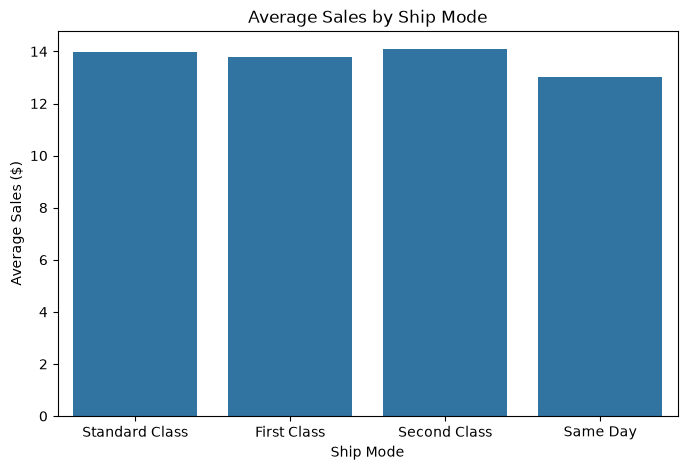

In [42]:
# Sales by Ship Mode

plt.figure(figsize=(8, 5))

sns.barplot(
    data = df,
    x = "Ship Mode",
    y = "Sales",
    estimator="mean",
    errorbar=None
)

plt.title("Average Sales by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Average Sales ($)")

plt.show()

## Observation

- Second Class has the highest average sales ($14.08).
- Same Day has the lowest average sales ($13.00).
- The difference in average sales across ship modes is relatively small (approximately $1), - -  - indicating that sales performance is fairly consistent regardless of shipping method.

## Business Insight:

Customers across different shipping modes contribute similar average sales, suggesting that shipping mode alone is not a major driver of revenue in this dataset.

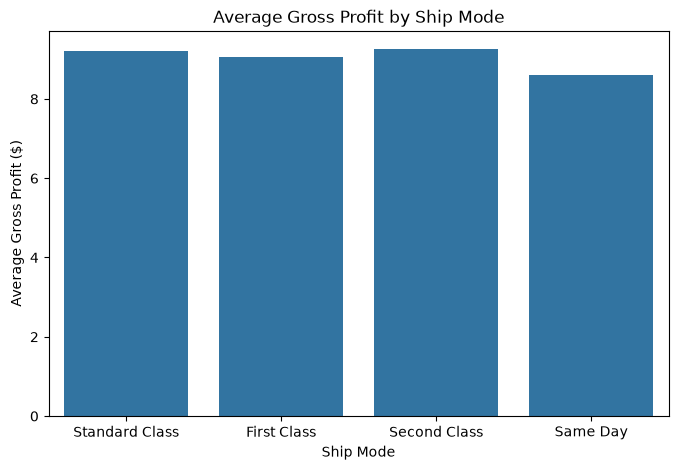

In [43]:
# Gross Profit by Ship Mode

plt.figure(figsize=(8, 5))

sns.barplot(
    data = df,
    x = "Ship Mode",
    y = "Gross Profit",
    estimator="mean",
    errorbar=None
)

plt.title("Average Gross Profit by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Average Gross Profit ($)")

plt.show()

## Observation

- Second Class generates the highest average gross profit ($9.25).
- Same Day records the lowest average gross profit ($8.59).
- Gross profit differences among ship modes are minimal.

## Business Insight:

Profitability remains relatively consistent across shipping methods, with only slight variations in average gross profit.

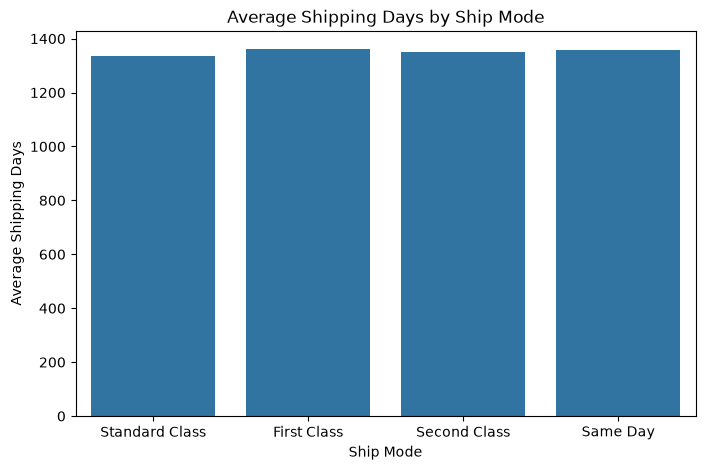

In [44]:
# Shipping Days by Ship Mode

plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Ship Mode",
    y="Shipping Days",
    estimator="mean",
    errorbar=None
)

plt.title("Average Shipping Days by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Average Shipping Days")


plt.show()

## Observation

- Average shipping days range from 1336.58 to 1360.13 days.
- The variation across ship modes is very small.
- The expected operational pattern (Same Day < First Class < Standard Class) is not observed.

## Business Insight:

Shipping duration does not significantly differ by ship mode in this dataset. This supports the earlier observation that the dataset likely contains synthetic shipping timelines.

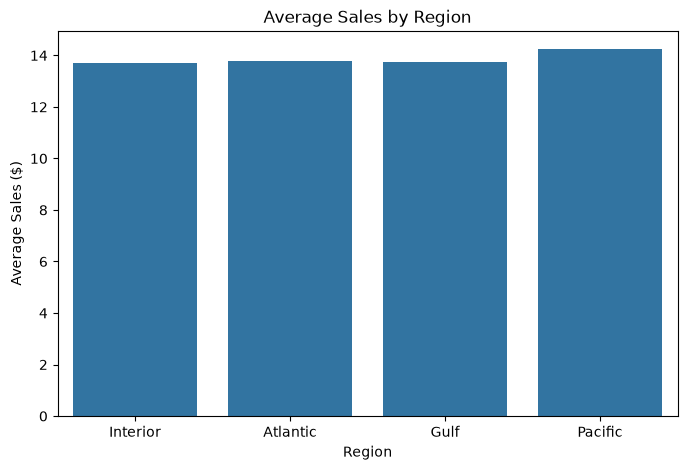

In [45]:
# Sales by Region

plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Region",
    y="Sales",
    estimator="mean",
    errorbar=None
)

plt.title("Average Sales by Region")
plt.xlabel("Region")
plt.ylabel("Average Sales ($)")

# plt.xticks(rotation=15)

plt.show()

## Observation

- Pacific region has the highest average sales ($14.23).
- Interior region has the lowest average sales ($13.72).
- Average sales are relatively balanced across all regions.

## Business Insight:

Regional sales performance is fairly consistent, with the Pacific region showing a slight advantage in average order value.

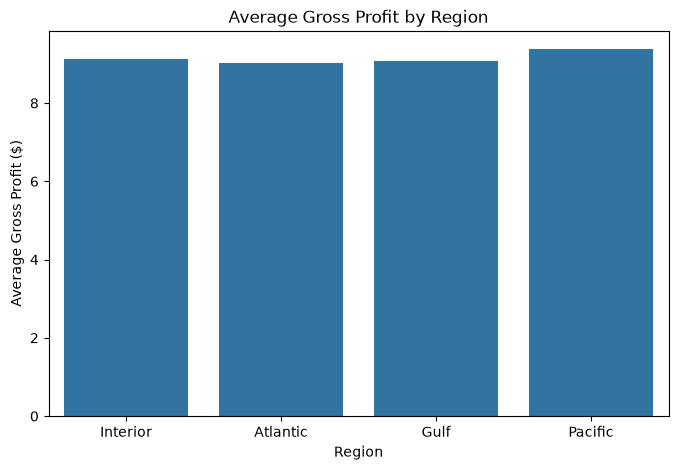

In [46]:
# Gross Profit by Region

plt.figure(figsize=(8, 5))

sns.barplot(
    data = df,
    x = "Region",
    y = "Gross Profit",
    estimator="mean",
    errorbar=None
)

plt.title("Average Gross Profit by Region")
plt.xlabel("Region")
plt.ylabel("Average Gross Profit ($)")

plt.show()

## Observation

- Pacific region records the highest average gross profit ($9.37).
- Atlantic region records the lowest average gross profit ($9.03).
- Profit differences between regions are relatively small.

## Business Insight:

Profitability is stable across regions, with the Pacific region contributing marginally higher average profits.

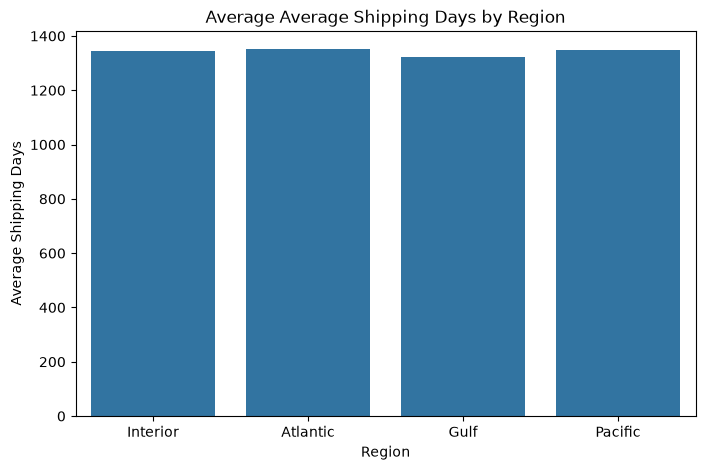

In [47]:
# Shipping Days by Region

plt.figure(figsize=(8, 5))

sns.barplot(
    data = df,
    x = "Region",
    y = "Shipping Days",
    estimator="mean",
    errorbar=None
)

plt.title("Average Average Shipping Days by Region")
plt.xlabel("Region")
plt.ylabel("Average Shipping Days")

plt.show()

## Observation

- Average shipping days range from 1323.10 to 1350.57 days.
- Atlantic has the lowest average shipping duration.
- Interior has the highest average shipping duration.
- Regional differences are small.

## Business Insight:

Shipping duration varies only slightly across regions, indicating no significant regional bottleneck based on this dataset.

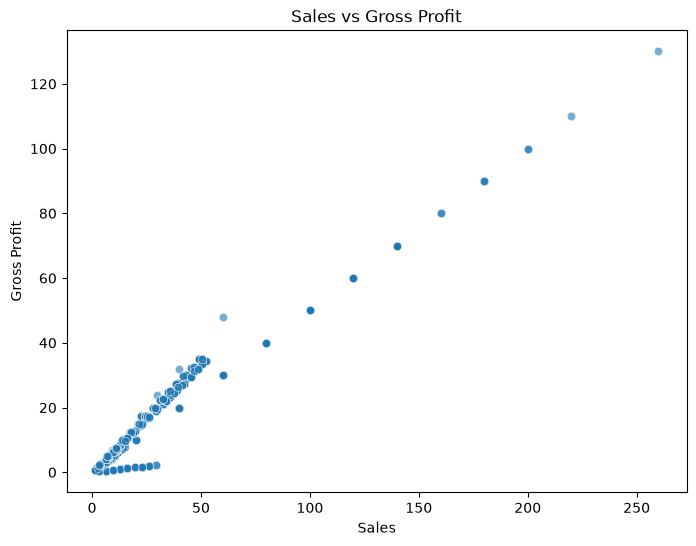

In [48]:
# Sales vs Gross profit

plt.figure(figsize=(8,6))

sns.scatterplot(
    data = df,
    x = "Sales",
    y = "Gross Profit",
    alpha = 0.6
)

plt.title("Sales vs Gross Profit")
plt.xlabel("Sales")
plt.ylabel("Gross Profit")

plt.show()

## Observation

- The scatter plot shows a clear upward trend.
- As sales increase, gross profit also increases.
- There are no unexpected negative relationships.

## Business Insight:

Higher sales consistently generate higher gross profit, demonstrating a strong positive business relationship.

In [49]:
# Correlation Between Sales and Gross Profit

correlation = df["Sales"].corr(df["Gross Profit"])

print(f"Correlation between Sales and Gross Profit: {correlation:.2f}")

Correlation between Sales and Gross Profit: 0.98


## Observation

Your calculated correlation:

`Correlation = 0.98`

## Interpretation
- The correlation coefficient of 0.98 indicates a very strong positive linear relationship between Sales and Gross Profit.
- Orders with higher sales almost always produce higher gross profit.

## Business Insight:

Sales is a strong predictor of gross profit within this dataset, which is expected in retail businesses.

In [50]:
# Business Summary Table

# Ship Mode Summary
ship_mode_summary = (
    df.groupby("Ship Mode")
      .agg({
          "Sales": "mean",
          "Gross Profit": "mean",
          "Shipping Days": "mean"
      })
      .round(2)
)

ship_mode_summary

,Sales,Gross Profit,Shipping Days
Ship Mode,,,
First Class,13.77,9.05,1360.13
Same Day,13.00,8.59,1356.49
Second Class,14.08,9.25,1352.12
Standard Class,13.97,9.22,1336.58


In [51]:
# Region Summary

region_summary = (
    df.groupby("Region")
      .agg({
          "Sales": "mean",
          "Gross Profit": "mean",
          "Shipping Days": "mean"
      })
      .round(2)
)

region_summary

,Sales,Gross Profit,Shipping Days
Region,,,
Atlantic,13.80,9.03,1350.57
Gulf,13.73,9.07,1323.10
Interior,13.72,9.11,1343.31
Pacific,14.23,9.37,1349.62


## Overall Bivariate Analysis Conclusion

- Sales and Gross Profit show a very strong positive correlation (0.98), indicating that higher sales generally result in higher profitability.
- Second Class records the highest average Sales and Gross Profit among all ship modes.
- Pacific region demonstrates the highest average Sales and Gross Profit.
- Shipping Days vary only slightly across ship modes and regions.
- The expected relationship between Ship Mode and Shipping Days is not observed, suggesting that shipping timelines in the dataset are synthetic or simulated.
- Despite this limitation, comparative analysis across regions and ship modes remains meaningful for identifying relative business performance.

## **Route Efficiency Analysis**

Objective

Identify:

- ✅ Fastest shipping routes
- ✅ Slowest shipping routes
- ✅ States with highest shipping duration
- ✅ Cities with highest shipping duration
- ✅ Best-performing regions
- ✅ Regional bottlenecks

In [52]:
# Shipping Days by State

state_shippng = (
    df.groupby("State/Province")
    .agg(
        Average_Shipping_Days = ("Shipping Days", "mean"),
        Total_Orders = ("Order ID", "count"),
        Total_Sales = ("Sales", "sum"),
        Total_Profit = ("Gross Profit", "sum")    
        )
        .sort_values(by="Average_Shipping_Days", ascending=False).round(2)
)

state_shippng.head(10)


,Average_Shipping_Days,Total_Orders,Total_Sales,Total_Profit
State/Province,,,,
North Dakota,1658.57,7,109.66,73.96
West Virginia,1623.25,4,63.97,43.89
New Brunswick,1566.75,8,172.72,118.72
Iowa,1470.57,30,400.37,269.97
New Mexico,1465.92,37,502.71,335.17
Nova Scotia,1458.67,6,87.50,56.90
Saskatchewan,1457.00,2,29.25,18.99
Vermont,1447.45,11,162.44,109.98
Manitoba,1440.33,12,138.25,90.27


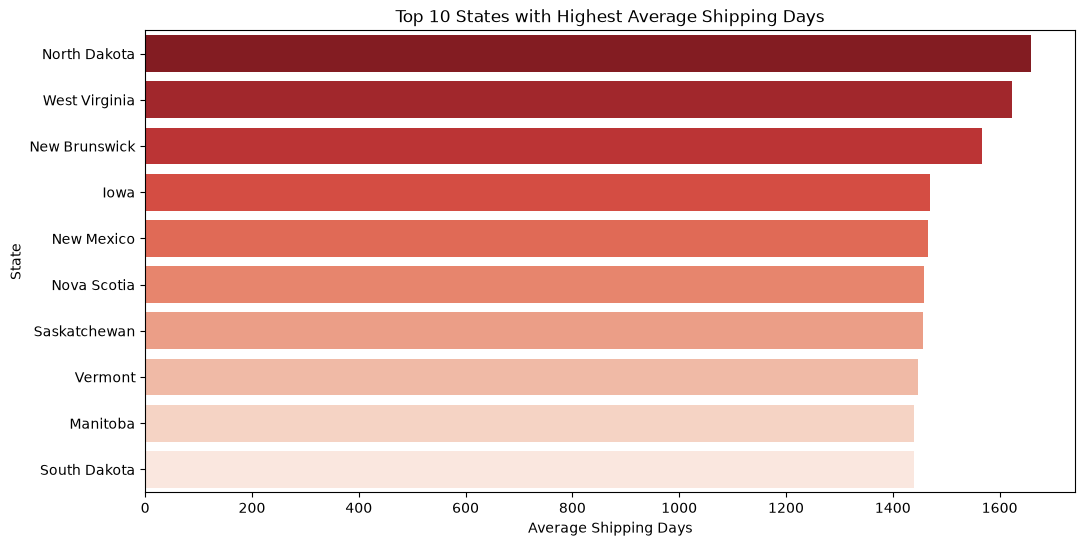

In [53]:
# Visualization

top10_state = state_shippng.head(10).reset_index()

plt.figure(figsize=(12,6))

sns.barplot(
    data = top10_state,
    x = "Average_Shipping_Days" ,
    y = "State/Province",
    palette= "Reds_r"
)

plt.title("Top 10 States with Highest Average Shipping Days")
plt.xlabel("Average Shipping Days")
plt.ylabel("State")

plt.show()

In [66]:
# Shipping Days by city

city_shipping = (
    df.groupby("City")
    .agg(
        Average_Shipping_Days = ("Shipping Days", "mean"),
        Total_Orders = ("Order ID", "count"),
        Total_Sales = ("Sales", "sum"),
        Total_Profit = ("Gross Profit", "sum")    
        )
        .sort_values(by="Average_Shipping_Days", ascending=False).round(2)
)

city_shipping.head(10)


,Average_Shipping_Days,Total_Orders,Total_Sales,Total_Profit
City,,,,
Saginaw,1910.17,6,85.06,58.72
Danville,1863.71,7,234.15,130.33
Bellingham,1863.67,3,89.25,59.05
Jupiter,1818.00,1,3.60,2.40
Modesto,1797.67,3,33.85,22.17
Sunnyvale,1791.17,6,162.00,82.28
Grove City,1786.00,2,43.50,28.90
Thornton,1782.20,10,165.64,109.60
La Mesa,1761.00,2,28.25,19.65


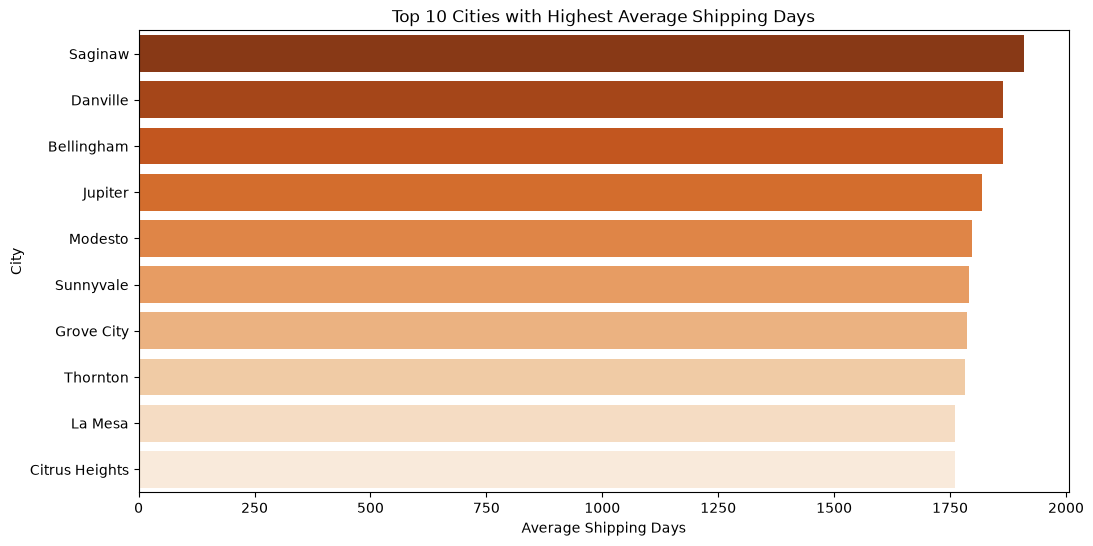

In [67]:
# Visualization

top10_city = city_shipping.head(10).reset_index()

plt.figure(figsize=(12,6))

sns.barplot(
    data = top10_city,
    x = "Average_Shipping_Days" ,
    y = "City",
    palette= "Oranges_r"
)

plt.title("Top 10 Cities with Highest Average Shipping Days")
plt.xlabel("Average Shipping Days")
plt.ylabel("City")

plt.show()

In [56]:
# Shipping Days by Region

region_shippng = (
    df.groupby("Region")
    .agg(
        Average_Shipping_Days = ("Shipping Days", "mean"),
        Total_Orders = ("Order ID", "count"),
        Total_Sales = ("Sales", "sum"),
        Total_Profit = ("Gross Profit", "sum")    
        )
        .sort_values(by="Average_Shipping_Days", ascending=False).round(2)
)

region_shippng


,Average_Shipping_Days,Total_Orders,Total_Sales,Total_Profit
Region,,,,
Atlantic,1350.57,2986,41197.24,26973.70
Pacific,1349.62,3253,46301.53,30485.94
Interior,1343.31,2335,32037.60,21282.49
Gulf,1323.10,1620,22247.26,14700.67


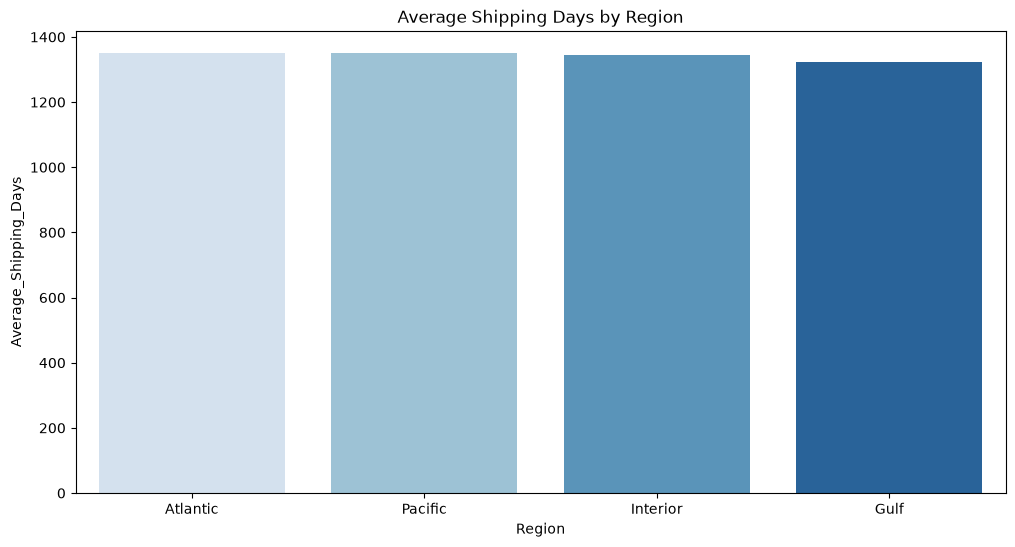

In [57]:
# Visualization

plt.figure(figsize=(12,6))

sns.barplot(
    data = region_shippng.reset_index(),
    x = "Region" ,
    y = "Average_Shipping_Days",
    palette= "Blues"
)

plt.title("Average Shipping Days by Region")

plt.show()

In [68]:
# Top 10 Fastest City
fastest_city = (
    city_shipping.sort_values("Average_Shipping_Days").head(10)
)
fastest_city

,Average_Shipping_Days,Total_Orders,Total_Sales,Total_Profit
City,,,,
Romeoville,644.00,1,6.98,4.98
Linden,675.00,1,25.20,16.80
Royal Oak,750.50,2,13.70,9.22
Andover,858.00,4,46.81,32.31
Vacaville,877.00,1,35.75,23.21
Margate,879.00,1,10.47,7.47
Rock Hill,904.00,1,9.75,6.33
Billings,904.00,1,7.50,4.90
Hackensack,905.83,6,99.75,68.03


In [69]:
# Top 10 Slowest City
slowest_city = (
    city_shipping.head(10)
)
slowest_city

,Average_Shipping_Days,Total_Orders,Total_Sales,Total_Profit
City,,,,
Saginaw,1910.17,6,85.06,58.72
Danville,1863.71,7,234.15,130.33
Bellingham,1863.67,3,89.25,59.05
Jupiter,1818.00,1,3.60,2.40
Modesto,1797.67,3,33.85,22.17
Sunnyvale,1791.17,6,162.00,82.28
Grove City,1786.00,2,43.50,28.90
Thornton,1782.20,10,165.64,109.60
La Mesa,1761.00,2,28.25,19.65


In [70]:
# Route Performance Score
city_shipping["Route Score"] = (
    city_shipping["Total_Profit"]/
    city_shipping["Average_Shipping_Days"]
).round(2)

city_shipping.head()

,Average_Shipping_Days,Total_Orders,Total_Sales,Total_Profit,Route Score
City,,,,,
Saginaw,1910.17,6,85.06,58.72,0.03
Danville,1863.71,7,234.15,130.33,0.07
Bellingham,1863.67,3,89.25,59.05,0.03
Jupiter,1818.00,1,3.60,2.40,0.00
Modesto,1797.67,3,33.85,22.17,0.01


In [83]:
city_shipping_filtered = city_shipping[city_shipping["Total_Orders"] >= 10]

# Best Performing Routes
best_routes = city_shipping_filtered.sort_values(
    by="Route Score",
    ascending=False
).head(10)

# Lowest Performing Routes
worst_routes = city_shipping_filtered.sort_values(
    by="Route Score",
    ascending=True
).head(10)

In [84]:
print("Best Performance Route:")
best_routes

Best Performance Route:


,Average_Shipping_Days,Total_Orders,Total_Sales,Total_Profit,Route Score
City,,,,,
New York City,1379.48,915,12514.90,8240.51,5.97
Los Angeles,1316.20,747,10408.75,6898.61,5.24
Philadelphia,1354.35,537,7415.52,4813.82,3.55
San Francisco,1336.25,510,7018.61,4650.77,3.48
Seattle,1385.93,428,5893.39,3880.68,2.80
Houston,1310.59,377,5429.41,3547.43,2.71
Chicago,1335.61,314,4263.92,2800.58,2.10
Columbus,1343.30,222,3357.39,2159.03,1.61
San Diego,1301.46,170,2348.88,1567.52,1.20


In [85]:
print("Lowest Performance Route:")
worst_routes

Lowest Performance Route:


,Average_Shipping_Days,Total_Orders,Total_Sales,Total_Profit,Route Score
City,,,,,
Carlsbad,1525.45,11,120.74,80.40,0.05
Belleville,1450.60,10,111.82,74.32,0.05
Bowling Green,1427.00,10,105.40,70.50,0.05
Boynton Beach,1436.50,10,99.19,67.43,0.05
Suffolk,1411.00,10,113.98,75.76,0.05
Freeport,1344.20,10,100.83,68.51,0.05
Meriden,1358.27,11,114.30,73.14,0.05
Madison,1513.70,10,133.72,91.72,0.06
Winnipeg,1440.33,12,138.25,90.27,0.06


## Overall Route Efficiency Analysis

### State Analysis
- North Dakota has the highest average shipping duration.
- States with fewer orders should be interpreted carefully due to limited data.

### City Analysis
- Saginaw records the highest average shipping duration.
- Romeoville records the lowest average shipping duration.
- Many cities in both the fastest and slowest groups have very low transaction counts.

### Region Analysis
- Atlantic has the highest average shipping duration.
- Gulf has the lowest average shipping duration.
- Regional differences are relatively small.

### Route Performance
- New York City has the highest Route Score, indicating strong profitability relative to shipping duration.
- Several cities have Route Scores close to zero, largely due to low sales, low profit, and very small order volumes.

### Business Insights
- Major metropolitan cities such as New York City and Los Angeles demonstrate the strongest overall route performance.
- Cities with low Route Scores should be reviewed alongside order volume before drawing operational conclusions.
- The dataset is suitable for comparative route analysis, although absolute shipping durations appear to be synthetic.

In [73]:
city_shipping_filtered = city_shipping[city_shipping["Total_Orders"] >= 10]

best_routes = city_shipping_filtered.sort_values(
    by="Route Score",
    ascending=False
).head(10)

worst_routes = city_shipping_filtered.sort_values(
    by="Route Score",
    ascending=True
).head(10)

In [75]:
best_routes

,Average_Shipping_Days,Total_Orders,Total_Sales,Total_Profit,Route Score
City,,,,,
New York City,1379.48,915,12514.90,8240.51,5.97
Los Angeles,1316.20,747,10408.75,6898.61,5.24
Philadelphia,1354.35,537,7415.52,4813.82,3.55
San Francisco,1336.25,510,7018.61,4650.77,3.48
Seattle,1385.93,428,5893.39,3880.68,2.80
Houston,1310.59,377,5429.41,3547.43,2.71
Chicago,1335.61,314,4263.92,2800.58,2.10
Columbus,1343.30,222,3357.39,2159.03,1.61
San Diego,1301.46,170,2348.88,1567.52,1.20


## correlation Analysis

In [88]:
# Numerical Column for correlation
corr_column = [
    "Sales",
    "Units", 
    "Cost",
    "Gross Profit",
    "Shipping Days",
    "Profit Margin (%)"
]

corr_metrix = df[corr_column].corr()

corr_metrix

,Sales,Units,Cost,Gross Profit,Shipping Days,Profit Margin (%)
Sales,1.000000,0.729347,0.958986,0.976404,0.007597,-0.111106
Units,0.729347,1.000000,0.563344,0.815820,0.002101,-0.013689
Cost,0.958986,0.563344,1.000000,0.875144,0.004963,-0.297219
Gross Profit,0.976404,0.815820,0.875144,1.000000,0.009187,0.036781
Shipping Days,0.007597,0.002101,0.004963,0.009187,1.000000,0.016457
Profit Margin (%),-0.111106,-0.013689,-0.297219,0.036781,0.016457,1.000000


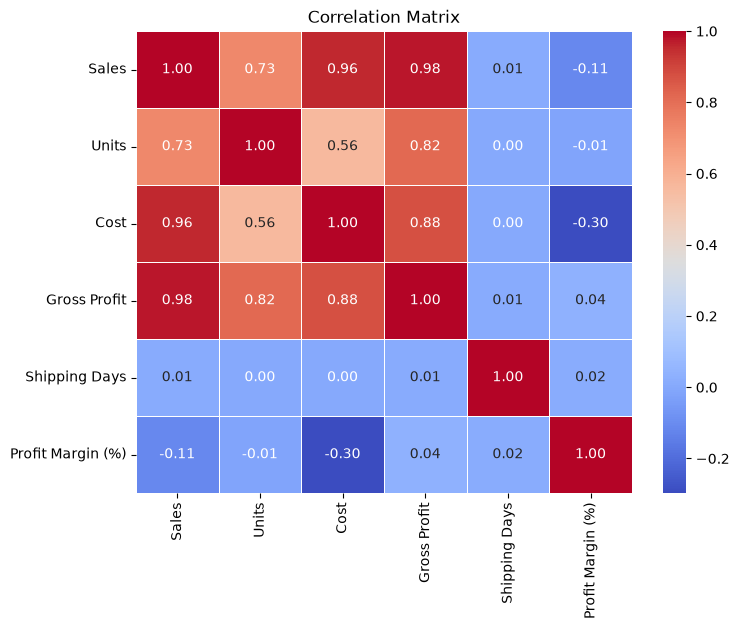

In [89]:
# Heatmap

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_metrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix")

plt.show()

## Correlation Analysis

- Sales and Gross Profit show a very strong positive correlation.
- Sales and Cost also have a strong positive relationship.
- Shipping Days have a weak relationship with financial metrics.
- Profit Margin has a moderate relationship with Sales and Gross Profit.
- The correlation analysis indicates that revenue-related variables are closely connected, while shipping duration has limited influence on profitability in this dataset.

## Final Business Insights

# Final Business Insights

### Sales Performance

- Total Sales generated: **$141,783.63**
- Average Sales per Order: **$13.91**
- Pacific region records the highest average sales.
- Second Class shipping has the highest average sales.

---

### Profitability

- Total Gross Profit: **$93,442.80**
- Average Profit Margin: **66.51%**
- Gross Profit has a strong positive relationship with Sales (Correlation = 0.98).

---

### Shipping Performance

- Shipping Days range between **491 and 1965** days.
- No negative shipping durations were found.
- Shipping duration varies only slightly across ship modes.
- Atlantic region has the highest average shipping duration.

---

### Route Performance

- New York City achieved the highest Route Score.
- Los Angeles and Philadelphia also demonstrate strong route performance.
- Several low-volume cities show poor Route Scores due to limited transactions.

---

### Data Quality

- No missing values.
- No duplicate records.
- Data types successfully converted.
- Feature engineering completed successfully.

## Business Recomendation

# Business Recommendations

### 1. Monitor High Shipping Duration Regions

Although differences are relatively small, the Atlantic region records the highest average shipping duration. Additional operational review may improve delivery efficiency.

---

### 2. Focus on High-Performing Routes

Cities such as New York City, Los Angeles, and Philadelphia consistently generate high sales and profit while maintaining strong Route Scores. These routes should remain a strategic priority.

---

### 3. Review Low-Performing Cities

Cities with low Route Scores should be reviewed. However, because many have very few orders, additional transaction data is required before making operational decisions.

---

### 4. Expand Successful Regions

The Pacific region demonstrates strong average sales and profit performance. Similar strategies may be applied in other regions.

---

### 5. Improve Data Collection

Shipping durations in this dataset are significantly higher than expected for real-world logistics, suggesting synthetic or simulated data. Future analyses would benefit from real operational shipping timestamps.

# **Final EDA Conclusion**

# EDA Conclusion

The exploratory data analysis successfully examined the Factory-to-Customer Shipping Route Efficiency dataset for Nassau Candy Distributor.

Major accomplishments include:

- Dataset successfully loaded and validated.
- No missing values or duplicate records were identified.
- Date fields were converted into datetime format.
- Shipping Days and Profit Margin features were engineered.
- Sales, Cost, Units, Gross Profit, and Shipping Days were analyzed using descriptive statistics and visualizations.
- Business KPIs were calculated.
- Route performance analysis identified high-performing and low-performing cities.
- Strong positive correlation was observed between Sales and Gross Profit.
- Comparative analysis across ship modes, regions, and routes provided valuable business insights.

Although shipping durations appear unrealistic for real-world logistics, the dataset remains suitable for comparative business analysis and dashboard development.

The insights generated through this EDA will support the development of a production-ready analytics pipeline and an interactive Streamlit dashboard for shipping route performance monitoring.